# Deep Learning
## Lab Assignment 6 - Multiclass Classification using Convolutional Neural Networks
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:

Build a Multiclass classifier using the CNN model. Use MNIST or any other suitable dataset.

a. Perform Data Pre-processing

b. Define Model and perform training

c. Evaluate Results using confusion matrix

## Load and Prepare Data

Load the Fashion MNIST dataset, split it into training and testing sets, reshape images for CNN input, normalize pixel values, and one-hot encode the labels.


In [ ]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [ ]:
import tensorflow as tf
import numpy as np

# 1. Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

# 2. Reshape images for CNN input
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

print(f"Reshaped x_train shape: {x_train.shape}")
print(f"Reshaped x_test shape: {x_test.shape}")

# 3. Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"x_train data type after normalization: {x_train.dtype}")
print(f"x_train min value: {np.min(x_train)}, max value: {np.max(x_train)}")

# 4. One-hot encode the labels
num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print(f"One-hot encoded y_train shape: {y_train.shape}")
print(f"One-hot encoded y_test shape: {y_test.shape}")

print("Data loaded and prepared successfully.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)
Reshaped x_train shape: (60000, 28, 28, 1)
Reshaped x_test shape: (10000, 28, 28, 1)
x_train data type after normalization: float32
x_train min value: 0.0, max value: 1.0
One-hot encoded y_train shape: (60000, 10)
One-hot encoded y_test shape: (10000, 10)
Data loaded and prepared successfully.


## Define CNN Model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, InputLayer

# 2. Initialize a sequential model
model = Sequential()

# Add an explicit InputLayer to address the UserWarning
model.add(InputLayer(shape=(28, 28, 1))) # Changed input_shape to shape

# 3. Add at least two Conv2D layers with appropriate filters, kernel size, 'relu' activation, and 'he_normal' kernel initializer.
# For the first Conv2D layer, specify the input_shape as (28, 28, 1).
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal'))
# 4. Add MaxPooling2D layers after each Conv2D layer
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal'))
model.add(MaxPooling2D((2, 2)))

# 5. Add a Flatten layer to convert the 2D feature maps into a 1D vector.
model.add(Flatten())

# 6. Add one or more Dense layers with 'relu' activation.
model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))

# 7. Add a final Dense layer with num_classes units and 'softmax' activation for multiclass classification.
model.add(Dense(num_classes, activation='softmax'))

# 8. Compile the model using the 'adam' optimizer, 'categorical_crossentropy' as the loss function, and 'accuracy' as the metric.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("CNN model defined and compiled successfully.")
model.summary()

CNN model defined and compiled successfully.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Train CNN Model

In [ ]:
epochs = 10
batch_size = 32

print(f"Training model with {epochs} epochs and batch size of {batch_size}...")
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test), verbose=1)

print("Model training complete.")

Training model with 10 epochs and batch size of 32...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.7994 - loss: 0.5603 - val_accuracy: 0.8704 - val_loss: 0.3494
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8913 - loss: 0.2967 - val_accuracy: 0.8916 - val_loss: 0.2911
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9138 - loss: 0.2349 - val_accuracy: 0.9017 - val_loss: 0.2703
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9234 - loss: 0.2060 - val_accuracy: 0.9053 - val_loss: 0.2592
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9329 - loss: 0.1776 - val_accuracy: 0.9107 - val_loss: 0.2555
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9443 - loss: 0.1489 - val_accuracy: 0.9124 - val_loss: 0.2531
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9535 - loss: 0.1282 - val_accuracy: 0.9101 - val_loss: 0.2696
Epoch 8/10
1875/1875 ━

## Evaluate Model and Generate Confusion Matrix


Evaluating model on test data...
Test Loss: 0.3099
Test Accuracy: 0.9125
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Confusion Matrix:

[[845   1  20  13   5   3 109   0   3   1]
 [  2 981   3   9   3   0   1   0   1   0]
 [ 15   1 881   7  43   0  52   0   1   0]
 [ 16   8   8 913  26   0  28   1   0   0]
 [  1   0  55  18 887   0  38   0   1   0]
 [  0   0   0   0   0 985   1   9   1   4]
 [105   1  55  21  90   0 725   1   2   0]
 [  0   0   0   0   0  18   0 971   0  11]
 [  2   0   0   3   5   3   4   1 982   0]
 [  1   0   0   0   0   9   0  35   0 955]]


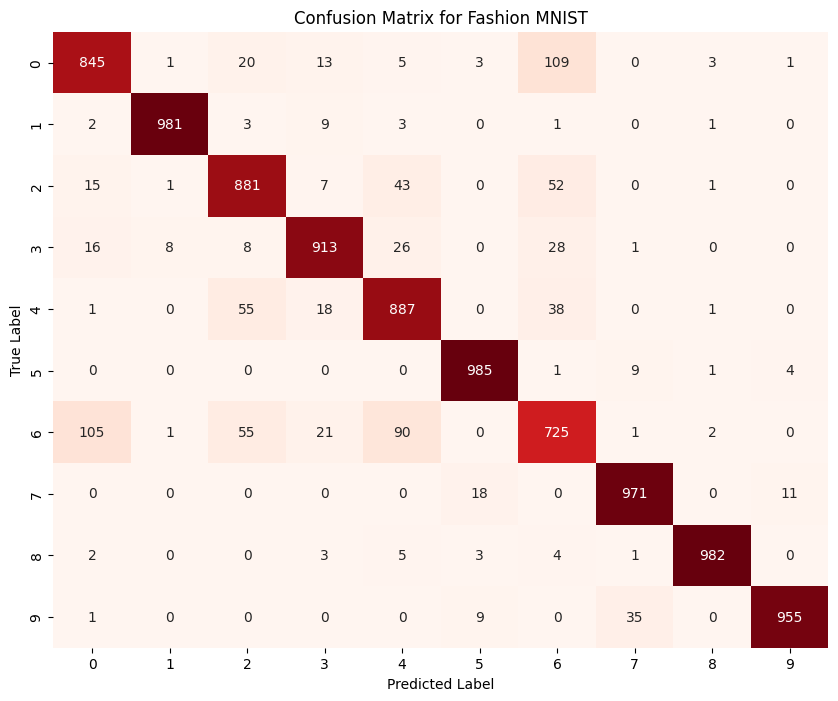

Model evaluation and confusion matrix generation complete.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Evaluate the trained CNN model on the test data
print("Evaluating model on test data...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# 2. Generate predictions for the test set
y_pred_probs = model.predict(x_test)

# 3. Convert one-hot encoded labels and predicted probabilities to single class labels
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# 5. Visualize the confusion matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Fashion MNIST')
plt.show()

print("Model evaluation and confusion matrix generation complete.")

## Summary:

### Data Analysis Key Findings

*   The model achieved a test accuracy of 0.9125 (91.25%) with a test loss of 0.3099.
*   The confusion matrix reveals strong performance for several classes, notably:
    *   **Class 5 (Sandal)**: Very high accuracy with 985 true positives and only 15 misclassifications across all other classes.
    *   **Class 1 (Trouser)**: High accuracy with 981 true positives and only 19 misclassifications.
    *   **Class 8 (Bag)**: Strong performance with 982 true positives and minimal misclassifications.
*   Some classes exhibit a higher degree of confusion:
    *   **Class 0 (T-shirt/top)**: Often misclassified as Class 6 (Shirt), with 109 instances.
    *   **Class 6 (Shirt)**: Frequently confused with Class 0 (T-shirt/top), with 105 instances, and also with Class 4 (Coat) (90 instances) and Class 2 (Pullover) (55 instances). This indicates a challenge in distinguishing between similar apparel items.
    *   **Class 2 (Pullover)**: Shows some confusion with Class 4 (Coat) (43 instances) and Class 6 (Shirt) (52 instances).
    *   **Class 4 (Coat)**: Misclassified as Class 2 (Pullover) (55 instances) and Class 6 (Shirt) (38 instances) relatively often.

### Insights or Next Steps

*   The model generally performs well, but there is clear confusion among visually similar clothing items like "T-shirt/top," "Pullover," "Coat," and "Shirt." Future efforts should focus on enhancing feature extraction to better differentiate these classes.
*   Consider implementing class-specific data augmentation, focusing on images from the more confused classes, or exploring attention mechanisms within the CNN to highlight discriminative features for these challenging categories.
